In [2]:
import pandas as pd

# load your dataset
df = pd.read_csv("/home/maryammahmood/Fati_Work/tree_trait_matrix.csv")

# count non-null values in each column
non_null_counts = df.notna().sum()

# get the column with the maximum filled values
most_filled_column = non_null_counts.idxmax()
max_count = non_null_counts.max()

print("Most filled column:", most_filled_column)
print("Number of non-null values:", max_count)

Most filled column: SpeciesName
Number of non-null values: 345845


In [3]:
import pandas as pd

df = pd.read_csv("/home/maryammahmood/Fati_Work/tree_trait_matrix.csv")

# count non-null values per column
non_null_counts = df.notna().sum()

# get top 10 most filled columns
top_10 = non_null_counts.sort_values(ascending=False).head(10)

print(top_10)

SpeciesName                     345845
Plant growth form               326139
Plant woodiness                  93427
Plant lifespan (longevity)       31254
Fruit type                       15402
Flower sex                       14761
Flower color                     11308
Wood growth ring distinction      5286
Plant human usage types           4472
Seed germination requirement      3810
dtype: int64


In [4]:
total_rows = len(df)

top_10_percent = (non_null_counts / total_rows * 100)\
                    .sort_values(ascending=False)\
                    .head(10)

print(top_10_percent)

SpeciesName                     100.000000
Plant growth form                94.302072
Plant woodiness                  27.014125
Plant lifespan (longevity)        9.036996
Fruit type                        4.453440
Flower sex                        4.268097
Flower color                      3.269673
Wood growth ring distinction      1.528430
Plant human usage types           1.293065
Seed germination requirement      1.101650
dtype: float64


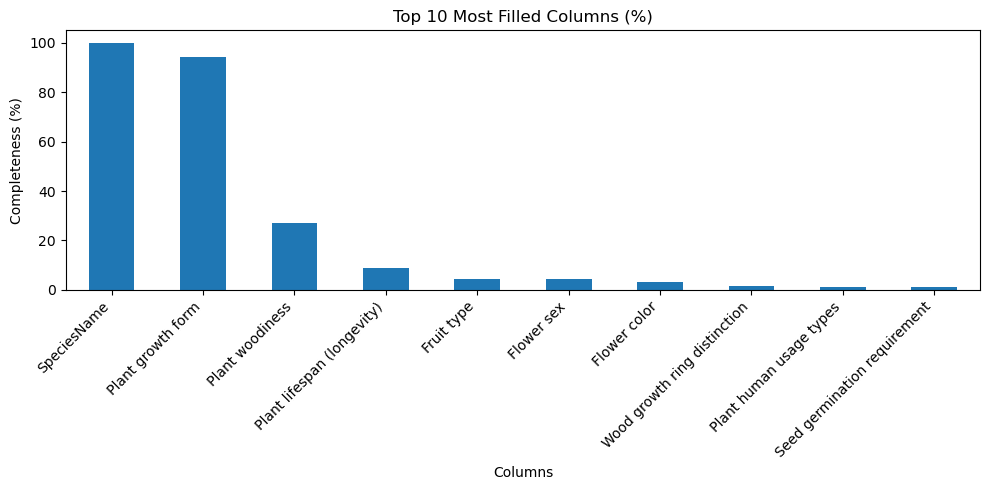

In [5]:
import matplotlib.pyplot as plt

total_rows = len(df)

top_10_percent = (df.notna().sum() / total_rows * 100)\
                    .sort_values(ascending=False)\
                    .head(10)

plt.figure(figsize=(10, 5))
top_10_percent.plot(kind='bar')

plt.title("Top 10 Most Filled Columns (%)")
plt.ylabel("Completeness (%)")
plt.xlabel("Columns")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

wfo = pd.read_csv("wfo_species_clean.csv")
traits = pd.read_csv("tree_trait_matrix.csv")

# normalize column names
wfo.columns = wfo.columns.str.lower()
traits.columns = traits.columns.str.lower()

print("WFO columns:", wfo.columns)
print("Traits columns:", traits.columns)

# find likely species column automatically
def find_species_col(df):
    for col in df.columns:
        if "species" in col or "scientific" in col or "taxon" in col:
            return col
    raise ValueError("No species column found")

wfo_col = find_species_col(wfo)
traits_col = find_species_col(traits)

# standardize names
wfo = wfo.rename(columns={wfo_col: "species"})
traits = traits.rename(columns={traits_col: "species"})

wfo["species"] = wfo["species"].str.strip().str.lower()
traits["species"] = traits["species"].str.strip().str.lower()

# merge without touching originals
merged = wfo.merge(traits, on="species", how="left")

merged.to_csv("wfo_trait_matched.csv", index=False)

print("Done. Rows:", len(merged))

WFO columns: Index(['id_x', 'alternativeid', 'basionymid', 'scientificname', 'authorship',
       'rank', 'uninomial', 'genus', 'infragenericepithet', 'specificepithet',
       'infraspecificepithet', 'code', 'referenceid_x', 'publishedinyear',
       'link_x', 'id_y', 'nameid', 'parentid', 'accordingtoid', 'scrutinizer',
       'scrutinizerid', 'scrutinizerdate', 'referenceid_y', 'extinct',
       'link_y'],
      dtype='str')
Traits columns: Index(['speciesname', 'flower color', 'flower sex',
       'flowering lag time: number of days from exposition start to flowering',
       'flowering requirement (requirement for fertility)', 'fruit type',
       'plant flowering', 'plant growth form',
       'plant growth temperature range', 'plant height',
       'plant human usage types', 'plant lifespan (longevity)',
       'plant lifespan: age trees reach in forested stands', 'plant woodiness',
       'seed germination base temperature',
       'seed germination base water potential', 'seed 

In [ ]:
import pandas as pd

# load datasets (read-only)
wfo = pd.read_csv("wfo_species_clean.csv")
traits = pd.read_csv("tree_trait_matrix.csv")

# standardize column names
wfo.columns = wfo.columns.str.lower()
traits.columns = traits.columns.str.lower()

# detect species columns
wfo_species_col = "scientificname"
traits_species_col = "speciesname"

# clean names (in-memory only)
wfo_species = wfo[wfo_species_col].str.strip().str.lower()
traits_species = traits[traits_species_col].str.strip().str.lower()

# create a set of WFO species for fast lookup
wfo_set = set(wfo_species)

# filter trait dataset to only WFO species
filtered_traits = traits[traits[traits_species_col].str.strip().str.lower().isin(wfo_set)]

# export ONLY filtered trait rows
filtered_traits.to_csv("traits_filtered_by_wfo.csv", index=False)

print("WFO species:", len(wfo_set))
print("Filtered trait rows:", len(filtered_traits))